In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [17]:
file_path = r"C:\Users\admin\Downloads\LC_loans_dataset.csv" 
df = pd.read_csv(file_path)

print(df.shape)
print(df.head())

C:\Users\admin\AppData\Local\Temp\ipykernel_12648\2509142939.py:2: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


(1347681, 15)
         id   issue_d   revenue  dti_n  loan_amnt  fico_n  experience_c  \
0  68407277  Dec-2015   55000.0   5.91       3600   677.0             1   
1  68355089  Dec-2015   65000.0  16.06      24700   717.0             1   
2  68341763  Dec-2015   71000.0  13.85      20000   697.0             1   
3  68476807  Dec-2015  104433.0  25.37      10400   697.0             1   
4  68426831  Dec-2015   34000.0  10.20      11950   692.0             1   

  emp_length             purpose home_ownership_n addr_state zip_code  \
0  10+ years  debt_consolidation         MORTGAGE         PA    190xx   
1  10+ years      small_business         MORTGAGE         SD    577xx   
2  10+ years    home_improvement         MORTGAGE         IL    605xx   
3    3 years      major_purchase         MORTGAGE         PA    174xx   
4    4 years  debt_consolidation             RENT         GA    300xx   

   Default               title desc  
0        0  Debt consolidation  NaN  
1        0          

**Preparing the feature**

In [18]:
df = pd.get_dummies(df, columns=["home_ownership_n"], drop_first=True, dtype=int)

feature_cols = ["loan_amnt", "revenue", "dti_n", "fico_n"] + \
               [c for c in df.columns if c.startswith("home_ownership_n_")]

X = df[feature_cols]
y = df["Default"]

print("Rows:", len(df))
print("Default rate:", round(y.mean() * 100, 2), "%")


Rows: 1347681
Default rate: 19.98 %


**Split into 70% training and 30% testing**

In [19]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


**Building Model and Making Prediction**


In [20]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
model.fit(X_train, y_train)


y_probs = model.predict_proba(X_test)[:, 1] 
y_preds = model.predict(X_test)

**Evaluating Model Performance**

In [21]:
print(classification_report(y_test, y_preds))

print("AUC Score:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.86      0.57      0.69    323530
           1       0.27      0.64      0.38     80775

    accuracy                           0.58    404305
   macro avg       0.57      0.61      0.53    404305
weighted avg       0.75      0.58      0.63    404305

AUC Score: 0.648615280544739


**Ploting ROC Curve**

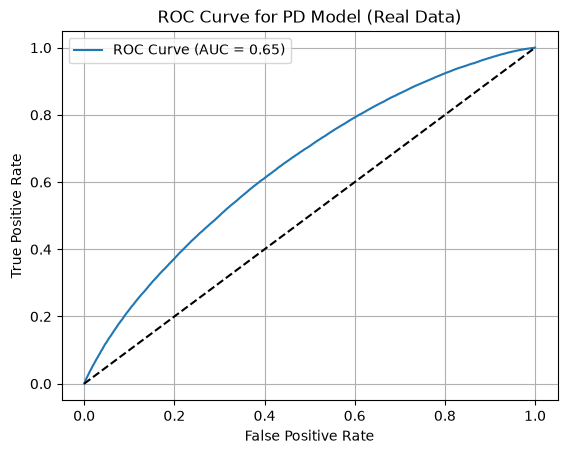

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % auc)
plt.plot([0, 1], [0, 1], "k--")              # Diagonal reference line (random guessing)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for PD Model (Real Data)")
plt.legend()
plt.grid(True)
plt.show()